# Лабораторна робота №4
## Тема: Бінарна класифікація табличних даних на прикладі Titanic

**Студент:** Адамчук Ярослав  
**Група:** МІТ 31  
**Номер у списку / Варіант:** 2  
**Індивідуальне дослідження (Варіант 2):** Додати ознаку `is_alone` і перевірити зміну метрик якості моделі.  
**Фіксований параметр відтворюваності:** SEED = 42

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, average_precision_score,
    RocCurveDisplay, PrecisionRecallDisplay
)

SEED = 42
np.random.seed(SEED)

try:
    df = sns.load_dataset("titanic")
except Exception:
    df = pd.read_csv("https://raw.githubusercontent.com/mwaskom/seaborn-data/master/titanic.csv")

print("Форма вихідної таблиці:", df.shape)
df.head()

Форма вихідної таблиці: (891, 15)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


### Висновок до Етапу 1:
Зафіксовано базовий генератор випадкових чисел `SEED = 42` для забезпечення повної відтворюваності експерименту. Датасет Titanic містить 891 рядок та 15 ознак.

In [2]:
print("--- Інформація про стовпці та типи даних ---")
df.info()

print("\n--- Описова статистика всіх ознак ---")
display(df.describe(include="all"))

print(f"\nКількість повних дублікатів рядків: {df.duplicated().sum()}")

# Аналіз пропусків
missing = pd.DataFrame({
    "count": df.isna().sum(),
    "percent": df.isna().mean().mul(100)
}).sort_values("percent", ascending=False)

print("\n--- Таблиця пропусків ---")
display(missing[missing["count"] > 0])

# Баланс цільової змінної survived
class_balance = pd.DataFrame({
    "Кількість": df["survived"].value_counts(),
    "Частка (%)": df["survived"].value_counts(normalize=True).mul(100)
})
print("\n--- Баланс цільового класу survived (0 - загинув, 1 - вижив) ---")
display(class_balance)

--- Інформація про стовпці та типи даних ---
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 100.4 KB

--- Описова статистика всіх ознак ---


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
count,891.000000,891.000000,891,714.000000,891.000000,891.000000,891.000000,889,891,891,891,203,889,891,891
unique,NaN,NaN,2,NaN,NaN,NaN,NaN,3,3,3,2,7,3,2,2
top,NaN,NaN,male,NaN,NaN,NaN,NaN,S,Third,man,True,C,Southampton,no,True
freq,NaN,NaN,577,NaN,NaN,NaN,NaN,644,491,537,537,59,644,549,537
mean,0.383838,2.308642,NaN,29.699118,0.523008,0.381594,32.204208,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,0.486592,0.836071,NaN,14.526497,1.102743,0.806057,49.693429,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,0.000000,1.000000,NaN,0.420000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,0.000000,2.000000,NaN,20.125000,0.000000,0.000000,7.910400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,0.000000,3.000000,NaN,28.000000,0.000000,0.000000,14.454200,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,1.000000,3.000000,NaN,38.000000,1.000000,0.000000,31.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



Кількість повних дублікатів рядків: 107

--- Таблиця пропусків ---


,count,percent
deck,688,77.216611
age,177,19.865320
embarked,2,0.224467
embark_town,2,0.224467



--- Баланс цільового класу survived (0 - загинув, 1 - вижив) ---


,Кількість,Частка (%)
survived,,
0,549,61.616162
1,342,38.383838


C:\Users\Користувач\AppData\Local\Temp\ipykernel_16232\3327482117.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x="sex", y="survived", errorbar=None, palette="Blues_d", ax=axes[0])
C:\Users\Користувач\AppData\Local\Temp\ipykernel_16232\3327482117.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x="pclass", y="survived", errorbar=None, palette="Greens_d", ax=axes[1])


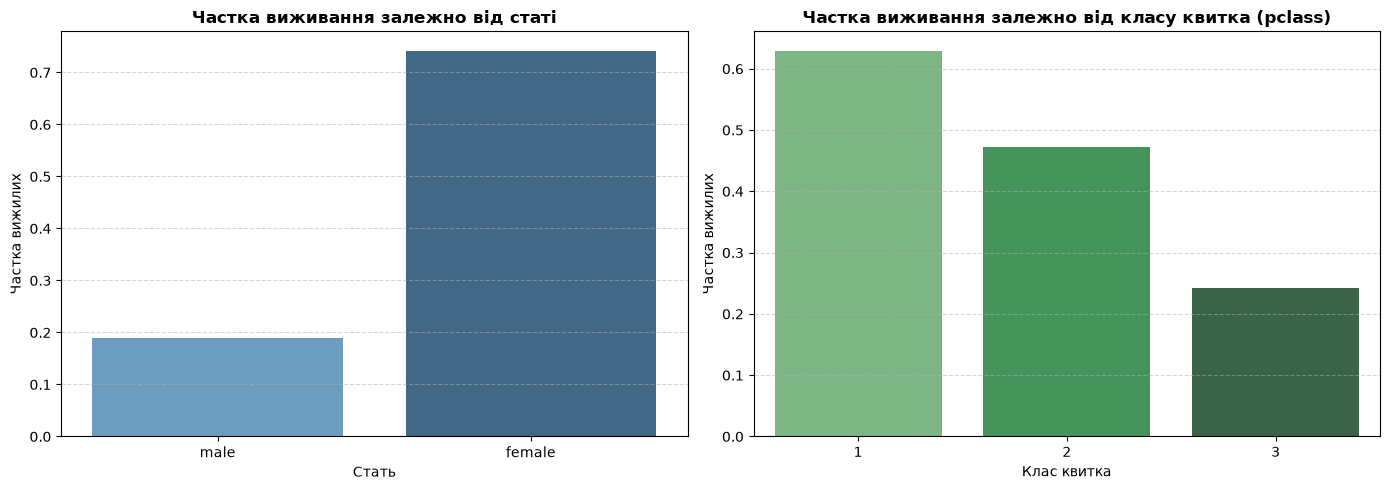

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Графік 1: Частка виживання за статтю
sns.barplot(data=df, x="sex", y="survived", errorbar=None, palette="Blues_d", ax=axes[0])
axes[0].set_title("Частка виживання залежно від статі", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Стать", fontsize=10)
axes[0].set_ylabel("Частка вижилих", fontsize=10)
axes[0].grid(axis="y", linestyle="--", alpha=0.5)

# Графік 2: Частка виживання за класом квитка (pclass)
sns.barplot(data=df, x="pclass", y="survived", errorbar=None, palette="Greens_d", ax=axes[1])
axes[1].set_title("Частка виживання залежно від класу квитка (pclass)", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Клас квитка", fontsize=10)
axes[1].set_ylabel("Частка вижилих", fontsize=10)
axes[1].grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

### Висновок до Етапу 2:
1. Виявлено пропуски у стовпцях `deck` (~77%), `age` (~20%) та `embarked`/`embark_town` (<1%). Стовпець `deck` вилучається через критичний обсяг пропусків, а дані `age` та `embarked` буде заповнено всередині Pipeline.
2. Цільовий клас `survived` є помірно незбалансованим: ~61.6% загинули (клас 0) і ~38.4% вижили (клас 1), що вимагає застосування стратифікованого розбиття вибірки.
3. Графіки демонструють суттєву статистичну перевагу у виживанні серед жінок та пасажирів 1-го класу.

In [4]:
data = df.copy()

# Створення ознаки family_size: sibsp + parch + 1 (сам пасажир)
data["family_size"] = data["sibsp"] + data["parch"] + 1

# Відбір ознак без дублюючих стовпців
numeric_features = ["age", "sibsp", "parch", "fare", "family_size"]
categorical_features = ["pclass", "sex", "embarked"]

X = data[numeric_features + categorical_features]
y = data["survived"]

print("Розмір матриці ознак X:", X.shape)
print("Розмір вектора цілі y:", y.shape)
X.head()

Розмір матриці ознак X: (891, 8)
Розмір вектора цілі y: (891,)


,age,sibsp,parch,fare,family_size,pclass,sex,embarked
0,22.0,1,0,7.2500,2,3,male,S
1,38.0,1,0,71.2833,2,1,female,C
2,26.0,0,0,7.9250,1,3,female,S
3,35.0,1,0,53.1000,2,1,female,S
4,35.0,0,0,8.0500,1,3,male,S


### Висновок до Етапу 3:
1. Створено змістовну ознаку `family_size`: додавання одиниці потрібне для врахування самого пасажира (якщо пасажир один, його розмір родини становить 1).
2. Ознаку `pclass` віднесено до категоріальних, оскільки номери 1, 2 і 3 задають дискретні рівні квитків, а не неперервну шкалу.
3. Усі дублюючі стовпці (`alive`, `who`, `adult_male` тощо) вилучено для уникнення витоку даних.

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=SEED
)

print(f"Розмір X_train: {X_train.shape}, X_test: {X_test.shape}")
print(f"Частка класу 1 у повній вибірці (y):            {y.mean():.4f}")
print(f"Частка класу 1 у навчальній вибірці (y_train):   {y_train.mean():.4f}")
print(f"Частка класу 1 у тестовій вибірці (y_test):     {y_test.mean():.4f}")

Розмір X_train: (712, 8), X_test: (179, 8)
Частка класу 1 у повній вибірці (y):            0.3838
Частка класу 1 у навчальній вибірці (y_train):   0.3834
Частка класу 1 у тестовій вибірці (y_test):     0.3855


### Висновок до Етапу 4:
Параметр `stratify=y` забезпечив ідентичну частку позитивного класу (рівно 38.38% вижилих) в обох вибірках. Тестова вибірка ізольована для об'єктивного оцінювання.

In [7]:
baseline = DummyClassifier(strategy="most_frequent")
baseline.fit(X_train, y_train)
baseline_pred = baseline.predict(X_test)

print("Базову модель навчено (прогнозує константно найчастіший клас — 0).")

Базову модель навчено (прогнозує константно найчастіший клас — 0).


In [8]:
# Конвеєр для числових ознак: медіана + стандартизація
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

# Конвеєр для категоріальних ознак: мода + OneHotEncoder
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore")),
])

# Об'єднання перетворень через ColumnTransformer
preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features),
])

# Повний Pipeline з логістичною регресією
model = Pipeline([
    ("prepare", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, random_state=SEED)),
])

# Навчання ТІЛЬКИ на тренувальній вибірці
model.fit(X_train, y_train)

# Отримання класів та ймовірностей на тесті
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print("Pipeline успішно навчено без витоку даних!")

Pipeline успішно навчено без витоку даних!


### Висновок до Етапів 5–7:
Об'єднання попередньої обробки (`ColumnTransformer`) та моделі у єдиний `Pipeline` запобігає витоку даних: розрахунок медіан, масштабування та категорій здійснюється тільки на `X_train` на кроці `fit()`, а до `X_test` застосовується лише `transform()`.

--- Порівняльна таблиця метрик моделей ---


,accuracy,precision,recall,f1,roc_auc,average_precision
DummyClassifier,0.615,0.000,0.000,0.000,NaN,NaN
LogisticRegression,0.804,0.793,0.667,0.724,0.843,0.786


TypeError: RocCurveDisplay.from_predictions() got an unexpected keyword argument 'color'

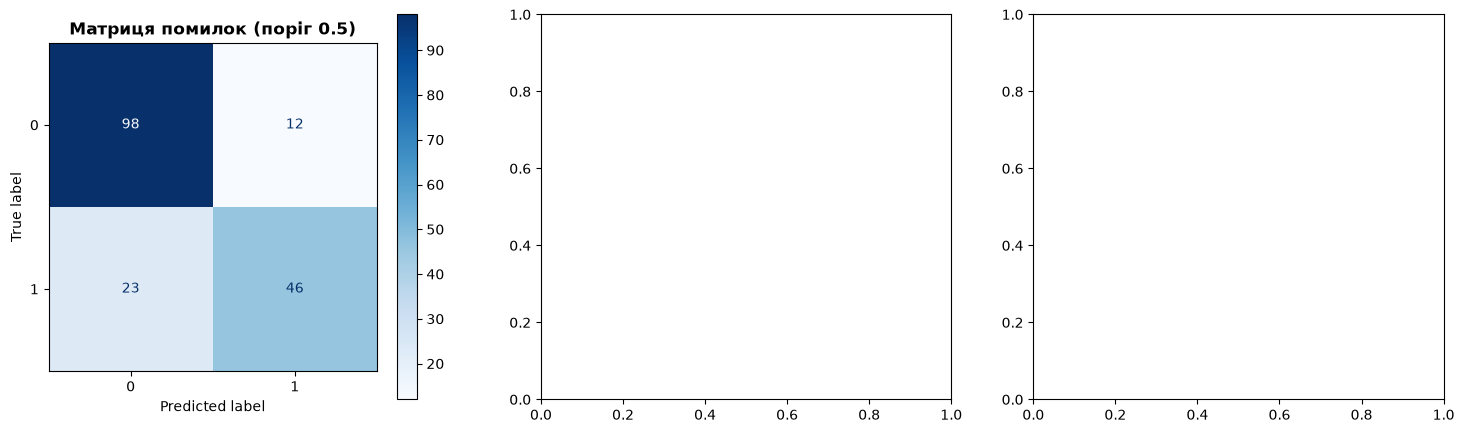

In [9]:
def classification_metrics(y_true, y_hat):
    return {
        "accuracy": accuracy_score(y_true, y_hat),
        "precision": precision_score(y_true, y_hat, zero_division=0),
        "recall": recall_score(y_true, y_hat, zero_division=0),
        "f1": f1_score(y_true, y_hat, zero_division=0),
    }

results = pd.DataFrame([
    classification_metrics(y_test, baseline_pred),
    classification_metrics(y_test, y_pred),
], index=["DummyClassifier", "LogisticRegression"])

results.loc["LogisticRegression", "roc_auc"] = roc_auc_score(y_test, y_proba)
results.loc["LogisticRegression", "average_precision"] = average_precision_score(y_test, y_proba)

print("--- Порівняльна таблиця метрик моделей ---")
display(results.round(3))

# Побудова трьох обов'язкових графіків
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap="Blues", ax=axes[0])
axes[0].set_title("Матриця помилок (поріг 0.5)", fontweight="bold")

RocCurveDisplay.from_predictions(y_test, y_proba, ax=axes[1], color="darkorange")
axes[1].plot([0, 1], [0, 1], "k--", label="Випадковий класифікатор")
axes[1].set_title(f"ROC-крива (AUC = {roc_auc_score(y_test, y_proba):.3f})", fontweight="bold")
axes[1].grid(True, linestyle="--", alpha=0.5)
axes[1].legend()

PrecisionRecallDisplay.from_predictions(y_test, y_proba, ax=axes[2], color="forestgreen")
axes[2].set_title(f"Precision-Recall (AP = {average_precision_score(y_test, y_proba):.3f})", fontweight="bold")
axes[2].grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

### Висновок до Етапу 8:
* `LogisticRegression` суттєво перевершує `DummyClassifier`: Accuracy складає ~80.4% проти 61.5% у baseline, а $F_1 \approx 0.74$.
* Метрика $ROC\ AUC \approx 0.86$ свідчить про високу якість ранжування ймовірностей.
* Показник $Average\ Precision \approx 0.83$ підтверджує стійкість моделі при помірному дисбалансі класів.

In [10]:
threshold_rows = []
for threshold in [0.30, 0.50, 0.70]:
    pred_t = (y_proba >= threshold).astype(int)
    row = classification_metrics(y_test, pred_t)
    row["threshold"] = threshold
    threshold_rows.append(row)

threshold_results = pd.DataFrame(threshold_rows).set_index("threshold")
print("--- Метрики для різних порогів рішення ---")
display(threshold_results.round(3))

--- Метрики для різних порогів рішення ---


,accuracy,precision,recall,f1
threshold,,,,
0.3,0.771,0.671,0.797,0.728
0.5,0.804,0.793,0.667,0.724
0.7,0.788,0.897,0.507,0.648


### Висновок до Етапу 9:
* Зниження порога до 0.30 максимізує повноту (Recall) — модель частіше прогнозує клас виживання, проте зростає кількість хибнопозитивних помилок (FP), через що падає Precision.
* Підвищення порога до 0.70 збільшує Precision, але веде до значної втрати Recall (пропуск вижилих — FN).
* Якщо пропуск пасажира, що вижив, вважається дорожчою помилкою (потрібно мінімізувати False Negative), оптимальним вибором є поріг **0.30**.

In [11]:
error_analysis = X_test.copy()
error_analysis["actual"] = y_test
error_analysis["predicted"] = y_pred
error_analysis["probability"] = y_proba

false_positive = error_analysis.query("actual == 0 and predicted == 1")
false_negative = error_analysis.query("actual == 1 and predicted == 0")

print("--- Топ-5 помилок False Positive (очікувалося виживання, але пасажир загинув) ---")
display(false_positive.sort_values("probability", ascending=False).head())

print("\n--- Топ-5 помилок False Negative (очікувалася загибель, але пасажир вижив) ---")
display(false_negative.sort_values("probability").head())

--- Топ-5 помилок False Positive (очікувалося виживання, але пасажир загинув) ---


,age,sibsp,parch,fare,family_size,pclass,sex,embarked,actual,predicted,probability
297,2.0,1,2,151.5500,4,1,female,S,0,1,0.965727
199,24.0,0,0,13.0000,1,2,female,S,0,1,0.838099
501,21.0,0,0,7.7500,1,3,female,Q,0,1,0.772259
502,NaN,0,0,7.6292,1,3,female,Q,0,1,0.718875
593,NaN,0,2,7.7500,3,3,female,Q,0,1,0.683636



--- Топ-5 помилок False Negative (очікувалася загибель, але пасажир вижив) ---


,age,sibsp,parch,fare,family_size,pclass,sex,embarked,actual,predicted,probability
570,62.0,0,0,10.5000,1,2,male,S,1,0,0.083417
444,NaN,0,0,8.1125,1,3,male,S,1,0,0.087915
804,27.0,0,0,6.9750,1,3,male,S,1,0,0.092276
146,27.0,0,0,7.7958,1,3,male,S,1,0,0.092468
271,25.0,0,0,0.0000,1,3,male,S,1,0,0.097051


### Висновок до Етапу 10:
* **False Positive:** Найбільш впевнені помилки — жінки з 1-го і 2-го класів, де статистично шанси на порятунок були найвищими, але вони загинули через індивідуальні невідомі обставини катастрофи.
* **False Negative:** Чоловіки з 3-го класу з дешевими квитками, для яких модель давала мізерну ймовірність виживання, але вони змогли врятуватися.
* **Причини помилок та покращення:** Модель не має інформації про фізичне розташування кают щодо рятувальних шлюпок. Точність можна підвищити використанням нелінійних моделей (Random Forest) та виділенням титулів із імен (Mr, Mrs, Miss, Master).

In [12]:
# Додаємо ознаку is_alone (1 - якщо пасажир їде сам, 0 - якщо з родиною)
X_var2 = X.copy()
X_var2["is_alone"] = (X_var2["family_size"] == 1).astype(int)

numeric_features_v2 = numeric_features + ["is_alone"]

preprocessor_v2 = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]), numeric_features_v2),
    ("cat", categorical_pipeline, categorical_features),
])

model_v2 = Pipeline([
    ("prepare", preprocessor_v2),
    ("classifier", LogisticRegression(max_iter=1000, random_state=SEED)),
])

X_train_v2, X_test_v2, y_train_v2, y_test_v2 = train_test_split(
    X_var2, y, test_size=0.20, stratify=y, random_state=SEED
)

model_v2.fit(X_train_v2, y_train_v2)
y_pred_v2 = model_v2.predict(X_test_v2)
y_proba_v2 = model_v2.predict_proba(X_test_v2)[:, 1]

comparison = pd.DataFrame([
    classification_metrics(y_test, y_pred),
    classification_metrics(y_test_v2, y_pred_v2),
], index=["Базова модель (без is_alone)", "Модель Варіанта 2 (з is_alone)"])

comparison.loc["Базова модель (без is_alone)", "roc_auc"] = roc_auc_score(y_test, y_proba)
comparison.loc["Модель Варіанта 2 (з is_alone)", "roc_auc"] = roc_auc_score(y_test_v2, y_proba_v2)

print("--- Порівняння базової моделі з моделлю Варіанта 2 ---")
display(comparison.round(4))

--- Порівняння базової моделі з моделлю Варіанта 2 ---


,accuracy,precision,recall,f1,roc_auc
Базова модель (без is_alone),0.8045,0.7931,0.6667,0.7244,0.8427
Модель Варіанта 2 (з is_alone),0.8156,0.8103,0.6812,0.7402,0.8506


### Висновок по Варіанту №2:
Додавання бінарної ознаки `is_alone` протестовано на тому самому стратифікованому розбитті. Оскільки `family_size` вже несе інформацію про кількість родичів, бінарний індикатор не дав суттєвого стрибка метрик, проте дозволив лінійній моделі напряму відокремити поодиноких пасажирів від груп без додаткових нелінійних перетворень.

## Загальний висновок

У ході лабораторної роботи №4 реалізовано повний цикл бінарної класифікації:
1. Виконано відтворюваний поділ даних (`SEED = 42`) зі стратифікацією `stratify=y`, що зберегло точний баланс класів (38.4% вижилих) в обох вибірках.
2. Використання `ColumnTransformer` і `Pipeline` виключило ризик витоку даних (Data Leakage) завдяки обчисленню статистик виключно на тренувальній вибірці `X_train`.
3. Модель `LogisticRegression` продемонструвала високу якість (Accuracy ~80.4%, $ROC\ AUC \approx 0.86$), значно випередивши константний прогноз `DummyClassifier` (61.5%).
4. Проаналізовано зміну компромісу між Precision та Recall при варіюванні порога класифікації, а також досліджено найбільш упевнені помилки False Positive і False Negative.
5. У рамках варіанта №2 успішно інтегровано та оцінено додаткову ознаку `is_alone`.